In [27]:
import os
import glob
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

# Make the plots look nice
sns.set_theme(style="whitegrid")

In [28]:
# Point this to your specific directory
directory_path = "runs/qwen35_9b_v3/eval_results/"
json_files = [
    f for f in glob.glob(os.path.join(directory_path, "*.json")) 
    if os.path.basename(f) != "all_metrics.json"
]

data = []

for file_path in json_files:
    filename = os.path.basename(file_path)
    
    if "base" in filename:
        step = 0
    elif "final" in filename:
        step = 99999 
    else:
        try:
            step = int(filename.split("-")[1].split(".")[0])
        except:
            step = -1

    with open(file_path, 'r', encoding='utf-8') as f:
        content = json.load(f)
        
    metrics = content.get("metrics", {})
    per_field_acc = metrics.get("per_field_accuracy", {})
    per_field_metrics = metrics.get("per_field_metrics", {})
    hazard_binary = metrics.get("hazard_present_binary", {})
    
    # Helper to safely get macro_f1
    def get_f1(field):
        return per_field_metrics.get(field, {}).get("macro_f1", 0)
    
    # Helper to sum False Positives across all classes in a field
    def get_fp(field):
        labels = per_field_metrics.get(field, {}).get("labels", {})
        return sum(label_info.get("fp", 0) for label_info in labels.values())

    row = {
        "checkpoint": filename.replace(".json", ""),
        "step": step,
        
        # --- OVERALL METRICS ---
        "exact_match_accuracy": metrics.get("exact_match_accuracy", 0),
        "hazard_f1": hazard_binary.get("f1", 0),
        "hazard_recall": hazard_binary.get("recall", 0), 
        "samples_per_sec": metrics.get("samples_per_sec", 0),
        
        # --- PER-FIELD ACCURACY ---
        "hazard_label_acc": per_field_acc.get("hazard_label", 0),
        "hazard_present_acc": per_field_acc.get("hazard_present", 0),
        "zone_relation_acc": per_field_acc.get("zone_relation", 0),
        "object_state_acc": per_field_acc.get("object_state", 0),
        "object_direction_acc": per_field_acc.get("object_direction", 0),
        
        # --- PER-FIELD MACRO F1 ---
        "hazard_label_f1": get_f1("hazard_label"),
        "hazard_present_f1": get_f1("hazard_present"),
        "zone_relation_f1": get_f1("zone_relation"),
        "object_state_f1": get_f1("object_state"),
        "object_direction_f1": get_f1("object_direction"),
        
        # --- PER-FIELD FALSE POSITIVES ---
        "hazard_label_fp": get_fp("hazard_label"),
        "hazard_present_fp": get_fp("hazard_present"),
        "zone_relation_fp": get_fp("zone_relation"),
        "object_state_fp": get_fp("object_state"),
        "object_direction_fp": get_fp("object_direction")
    }
    data.append(row)

# Create DataFrame and sort it chronologically
df = pd.DataFrame(data)
df = df.sort_values("step").reset_index(drop=True)

# Preview the first few rows
df.head()

,checkpoint,step,exact_match_accuracy,hazard_f1,hazard_recall,samples_per_sec,hazard_label_acc,hazard_present_acc,zone_relation_acc,object_state_acc,...,hazard_label_f1,hazard_present_f1,zone_relation_f1,object_state_f1,object_direction_f1,hazard_label_fp,hazard_present_fp,zone_relation_fp,object_state_fp,object_direction_fp
0,base_pretrained,0,0.162,0.0,0.0,0.1582,0.7465,0.7465,0.2676,0.5915,...,0.4274,0.4274,0.2404,0.3867,0.3723,36,36,104,58,86
1,checkpoint-80,80,0.000,0.0,0.0,247.8113,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,142,142,142,142,142
2,checkpoint-160,160,0.000,0.0,0.0,251.8090,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,142,142,142,142,142
3,checkpoint-240,240,0.000,0.0,0.0,254.3309,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,142,142,142,142,142
4,checkpoint-320,320,0.000,0.0,0.0,255.9389,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,142,142,142,142,142


0 [-0.65687998 -0.30552654]
13 [-0.56236649 -0.84556516]
1 [-0.679718   -0.05402625]
14 [0.68089339 0.12552385]
27 [-0.16303504 -0.34815596]
40 [0.38167452 0.6725621 ]
53 [-0.96402458 -0.87024737]
2 [-0.44357357 -0.43950054]
15 [ 0.82945807 -0.79890801]
28 [-0.1660382  -0.46814207]
41 [ 0.82630566 -0.38658021]
54 [0.08375439 0.42177427]
3 [0.81707424 0.81504293]
16 [ 0.68448309 -0.93304267]
29 [0.40953175 0.40140265]
42 [ 0.79292285 -0.32445676]
55 [-0.69051845  0.44394355]
4 [ 0.41452413 -0.31307806]
17 [-0.17536713 -0.53885615]
30 [0.87412641 0.78184739]
43 [ 0.13764143 -0.52867758]
56 [ 0.41408788 -0.75650186]
5 [-0.44157479  0.09912858]
18 [-0.95718963 -0.75321418]
31 [-0.6243279  -0.67011064]
44 [-0.10418413 -0.08377845]
57 [-0.161347   -0.56855266]
6 [0.17243009 0.97908442]
19 [0.65638185 0.66001073]
32 [-0.59587104 -0.44502114]
45 [ 0.53350552 -0.72867283]
58 [ 0.27478727 -0.28313278]
7 [0.19123172 0.16769352]
20 [ 0.91936628 -0.18546392]
33 [-0.16494995 -0.29693597]
46 [ 0.9140

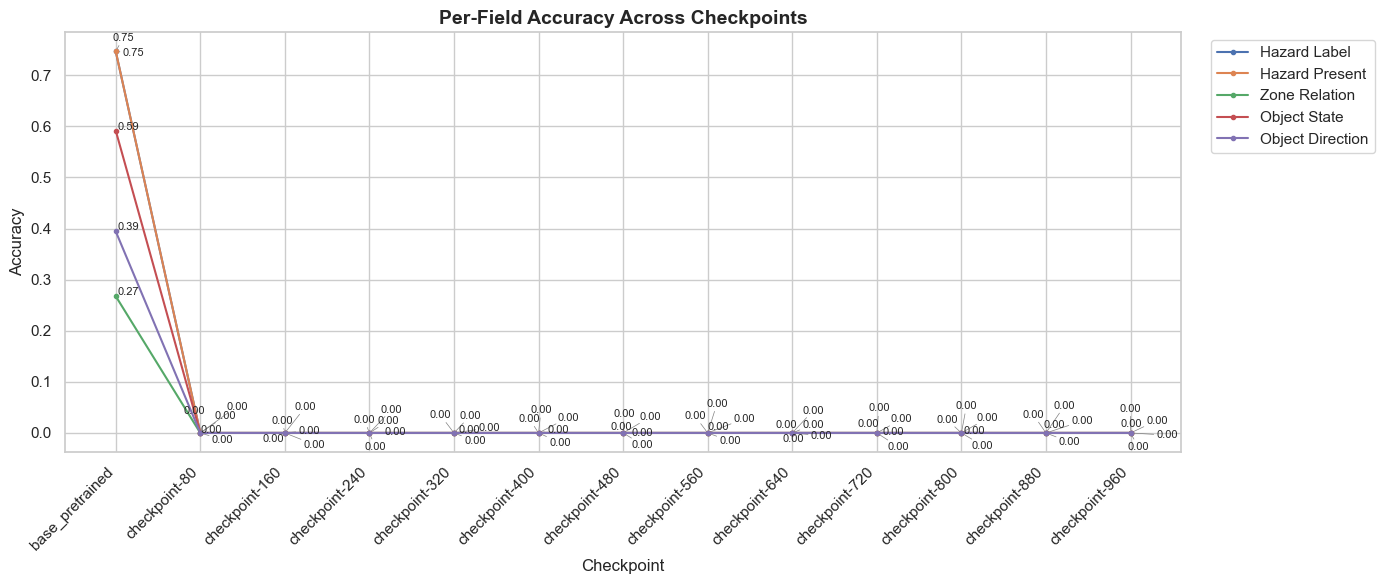

In [29]:
import matplotlib.pyplot as plt
from adjustText import adjust_text

# ... (assuming df is defined above this snippet) ...

fields_to_plot = [
    "hazard_label_acc", 
    "hazard_present_acc", 
    "zone_relation_acc", 
    "object_state_acc", 
    "object_direction_acc"
]

plt.figure(figsize=(14, 6))

# 1. Create an empty list to store the text objects
texts = []

for field in fields_to_plot:
    # Remove the "_acc" for a cleaner legend label
    clean_label = field.replace("_acc", "").replace("_", " ").title()
    plt.plot(df["checkpoint"], df[field], marker='.', label=clean_label, linewidth=1.5)
    
    for x, y in zip(df["checkpoint"], df[field]):
        # 2. Append the text object to the list (removed ha and va since adjust_text handles positioning)
        texts.append(plt.text(x, y, f'{y:.2f}', fontsize=8))

# 3. Call adjust_text on the list of text objects
# arrowprops draws a small line from the text to the point if it gets moved far away
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

plt.title("Per-Field Accuracy Across Checkpoints", fontsize=14, fontweight='bold')
plt.xlabel("Checkpoint", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.xticks(rotation=45, ha="right")

# Put the legend outside the chart so it doesn't cover the data
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left') 
plt.tight_layout()
plt.show()

0 [-0.73081853  0.97636001]
13 [-0.00371149 -0.38820206]
1 [-0.96037251  0.97491281]
14 [ 0.62705508 -0.18422433]
27 [-0.24615527  0.28398968]
40 [-0.35992036 -0.48627661]
53 [0.69528449 0.58731468]
2 [-0.52614714 -0.8880157 ]
15 [ 0.97612443 -0.38220976]
28 [ 0.90758478 -0.82843569]
41 [0.75149741 0.31550607]
54 [ 0.51068073 -0.50188198]
3 [-0.62305007 -0.7454886 ]
16 [ 0.31121807 -0.55782887]
29 [0.68480794 0.64637336]
42 [0.50015483 0.58855424]
55 [-0.5099773  -0.34840981]
4 [ 0.16743447 -0.43408374]
17 [ 0.43458896 -0.18078119]
30 [ 0.54600693 -0.39557455]
43 [ 0.27026715 -0.93862613]
56 [0.176387   0.66768244]
5 [-0.99127466 -0.61410136]
18 [ 0.55092814 -0.16762824]
31 [-0.42708744 -0.98947144]
44 [-0.61337247  0.38899053]
57 [0.2779528  0.39774672]
6 [ 0.51457502 -0.99901748]
19 [0.12013208 0.28722699]
32 [-0.65519185  0.31664021]
45 [ 0.10309181 -0.8653604 ]
58 [-0.65376094 -0.32632721]
7 [-0.54106224  0.18579659]
20 [0.44581314 0.68812798]
33 [0.22663638 0.75633561]
46 [-0.2888

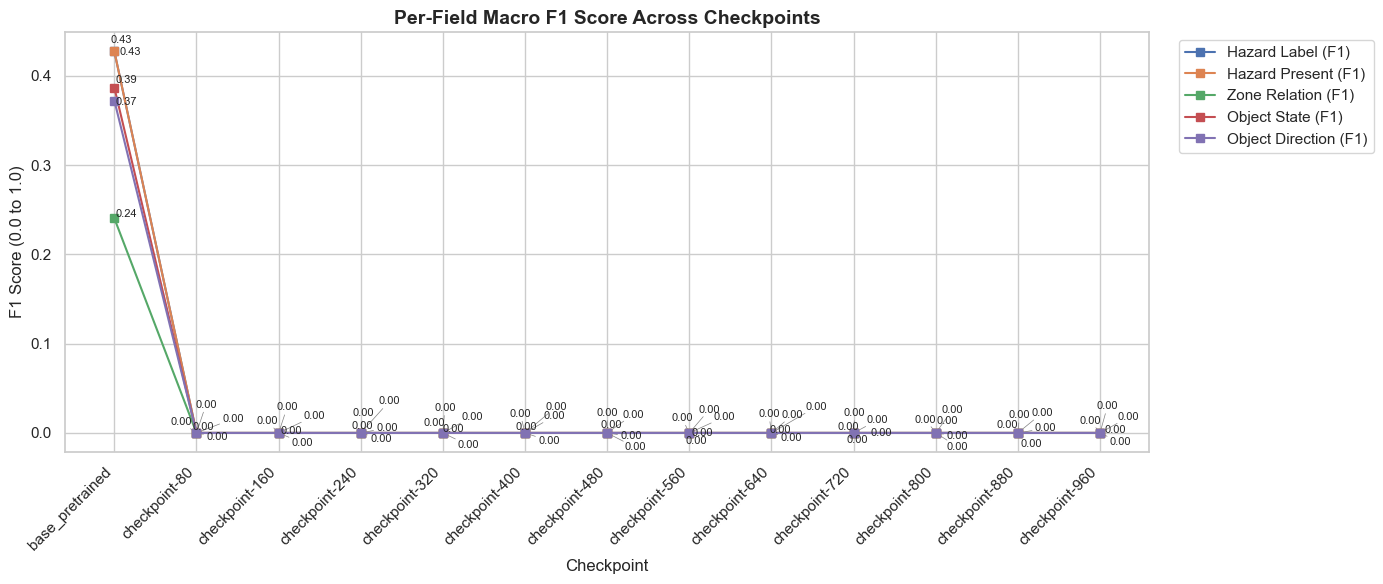

In [30]:
fields_to_plot_f1 = [
    "hazard_label_f1", 
    "hazard_present_f1", 
    "zone_relation_f1", 
    "object_state_f1", 
    "object_direction_f1"
]

plt.figure(figsize=(14, 6))

texts = [] # List to collect all the text objects

for field in fields_to_plot_f1:
    clean_label = field.replace("_f1", "").replace("_", " ").title() + " (F1)"
    plt.plot(df["checkpoint"], df[field], marker='s', label=clean_label, linewidth=1.5)
    
    # Create the text objects but don't finalize their positions yet
    for x, y in zip(df["checkpoint"], df[field]):
        texts.append(plt.text(x, y, f'{y:.2f}', fontsize=8))

# Let adjustText do the heavy lifting to prevent overlaps
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))

plt.title("Per-Field Macro F1 Score Across Checkpoints", fontsize=14, fontweight='bold')
plt.xlabel("Checkpoint", fontsize=12)
plt.ylabel("F1 Score (0.0 to 1.0)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left') 
plt.tight_layout()
plt.show()

0 [0.93505774 0.73934586]
13 [0.21519624 0.37766435]
1 [ 0.88554948 -0.20981866]
14 [-0.31518236  0.54132931]
27 [0.43654395 0.21643248]
40 [-0.2454101   0.32506112]
53 [0.36088639 0.28389509]
2 [ 0.28412206 -0.95947805]
15 [-0.60274958 -0.71544689]
28 [ 0.83162573 -0.11661465]
41 [-0.61845401  0.97570659]
54 [-0.30236808 -0.93043044]
3 [-0.00988679  0.6036965 ]
16 [0.72478128 0.38045572]
29 [-0.90343211 -0.88090968]
42 [0.14904103 0.33794435]
55 [-0.03228241 -0.85350406]
4 [-0.48591883  0.71078119]
17 [-0.95366673  0.59557652]
30 [-0.91323208  0.17680603]
43 [-0.18400699  0.1204491 ]
56 [-0.57893476 -0.86444461]
5 [-0.7305532  -0.10818571]
18 [-0.29371517 -0.85762599]
31 [-0.92345458  0.82038347]
44 [-0.20088991  0.29560931]
57 [-0.15058798 -0.70432424]
6 [-0.88292264  0.842932  ]
19 [ 0.71972997 -0.7324856 ]
32 [-0.46877355 -0.44986786]
45 [-0.92980083  0.9197922 ]
58 [-0.98864114 -0.69428193]
7 [0.87443867 0.87056871]
20 [-0.69681734  0.33775538]
33 [ 0.07726144 -0.15542758]
46 [0.4

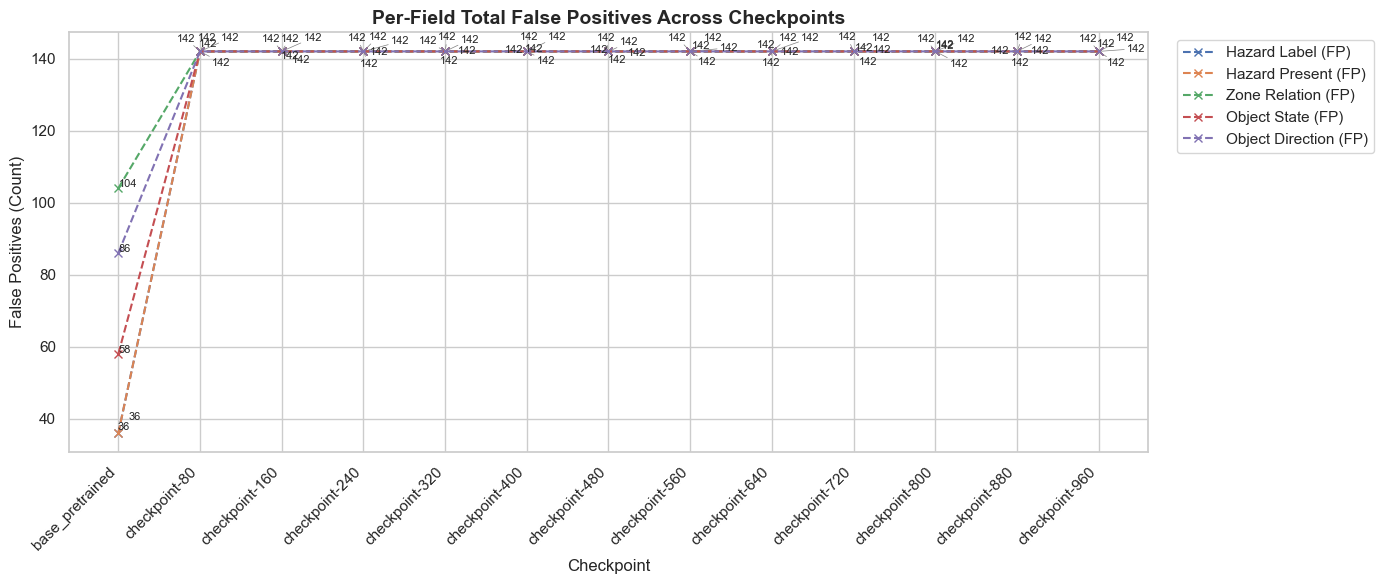

In [31]:
fields_to_plot_fp = [
    "hazard_label_fp", 
    "hazard_present_fp", 
    "zone_relation_fp", 
    "object_state_fp", 
    "object_direction_fp"
]

plt.figure(figsize=(14, 6))
texts = [] # List to collect text objects for automatic adjustment

for field in fields_to_plot_fp:
    # Formatting label for the legend
    clean_label = field.replace("_fp", "").replace("_", " ").title() + " (FP)"
    
    # Plotting with 'x' markers and dashed lines as requested
    plt.plot(df["checkpoint"], df[field], marker='x', label=clean_label, linewidth=1.5, linestyle='--')
    
    # Adding data labels to the list
    for x, y in zip(df["checkpoint"], df[field]):
        # Using int(y) for clean count labels
        texts.append(plt.text(x, y, f'{int(y)}', fontsize=8))

# This handles the magic of moving overlapping numbers
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))

plt.title("Per-Field Total False Positives Across Checkpoints", fontsize=14, fontweight='bold')
plt.xlabel("Checkpoint", fontsize=12)
plt.ylabel("False Positives (Count)", fontsize=12)
plt.xticks(rotation=45, ha="right")

# Place legend outside to the right
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left') 
plt.tight_layout()
plt.show()

In [32]:
import json

# Path to your evaluation JSON
file_path = "runs/qwen35_9b_lora_newprompt/eval_results/checkpoint-648.json"

def debug_mismatches_with_video(json_path):
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    samples = data.get("per_sample", [])
    
    # Updated headers to include Source Video ID
    print(f"{'Field':<18} | {'GT':<12} | {'Pred':<12} | {'Source Video ID':<45} | {'Sample ID'}")
    print("-" * 140)

    mismatch_count = 0

    for sample in samples:
        gt = sample.get("ground_truth", {})
        pred = sample.get("prediction_parsed", {})
        matches = sample.get("field_matches", {})
        
        # Pulling source_video_id from the 'meta' dictionary
        meta = sample.get("meta", {})
        video_id = meta.get("source_video_id", "N/A")
        sample_id = sample.get("sample_id", "Unknown")

        # Check every field for a False match
        for field, is_match in matches.items():
            if is_match is False:
                gt_val = gt.get(field, "N/A")
                pred_val = pred.get(field, "N/A")
                
                # Print the mismatch with the Video ID
                print(f"{field:<18} | {str(gt_val):<12} | {str(pred_val):<12} | {str(video_id):<45} | {sample_id}")
                mismatch_count += 1

    print("-" * 140)
    print(f"Total Mismatches Found: {mismatch_count}")

debug_mismatches_with_video(file_path)

Field              | GT           | Pred         | Source Video ID                               | Sample ID
--------------------------------------------------------------------------------------------------------------------------------------------
hazard_label       | unsafe_forklift_approach | no_hazard    | 동일유리02_S20250716113905_E20250716114050        | 동일유리02_S20250716113905_E20250716114050__000065000_000070000
hazard_present     | yes          | no           | 동일유리02_S20250716113905_E20250716114050        | 동일유리02_S20250716113905_E20250716114050__000065000_000070000
object_direction   | towards      | away         | 동일유리02_S20250716113905_E20250716114050        | 동일유리02_S20250716113905_E20250716114050__000065000_000070000
hazard_label       | unsafe_forklift_approach | no_hazard    | 금진Camera05_S20251213082156_E20251213083037    | 금진Camera05_S20251213082156_E20251213083037__000004000_000009000
hazard_present     | yes          | no           | 금진Camera05_S20251213082156_E2025121